In [1]:
import numpy as np
import matplotlib.pyplot as plt



def plot(R, I, eps, absorption=False):

    q_comp = R + 1j * I

    energy_term = (eps + q_comp) / (eps + 1j * 1)

    if absorption:
        energy_term = np.conjugate(energy_term)

    phase = np.unwrap(np.angle(energy_term))

    # extremums
    if I == 1:
        ext1 = - R / 2
        ext2 = np.inf
    else:
        ext1 = (-R - np.sqrt(I * ((I - 1) ** 2 + R ** 2))) / (1 - I)
        ext2 = (-R + np.sqrt(I * ((I - 1) ** 2 + R ** 2))) / (1 - I)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(np.real(energy_term), np.imag(energy_term))
    plt.scatter([np.real(energy_term)[0]], [np.imag(energy_term)[0]], marker="x", s=50, color="black")
    plt.scatter([np.real(energy_term)[-1]], [np.imag(energy_term)[-1]], marker="x", s=50, color="red")
    plt.axvline(0, linestyle="--", linewidth=1, color="black")
    plt.axhline(0, linestyle="--", linewidth=1, color="black")

    plt.subplot(1, 2, 2)
    plt.plot(eps, phase)

    if np.isfinite(ext1):
        plt.scatter([ext1], [np.interp(ext1, eps, phase)], marker="o", s=30, color="green")

    if np.isfinite(ext1):
        plt.scatter([ext2], [np.interp(ext2, eps, phase)], marker="o", s=30, color="orange")

    plt.axhline(0, linestyle="--", linewidth=1, color="black")

    return energy_term, phase, ext1, ext2, np.interp(ext1, eps, phase), np.interp(ext2, eps, phase)


def analyt_jump(R, I):

    if I == 0:
        return np.pi

    else:
        comp_number = 2 + np.sqrt(((1 - I) ** 2 + R ** 2) / I) * 1j
        return 2 * np.angle(comp_number)

C:\Users\shapo\AppData\Local\Temp\ipykernel_25516\4178538409.py:22: RuntimeWarning: invalid value encountered in sqrt
  ext1 = (-R - np.sqrt(I * ((I - 1) ** 2 + R ** 2))) / (1 - I)
C:\Users\shapo\AppData\Local\Temp\ipykernel_25516\4178538409.py:23: RuntimeWarning: invalid value encountered in sqrt
  ext2 = (-R + np.sqrt(I * ((I - 1) ** 2 + R ** 2))) / (1 - I)


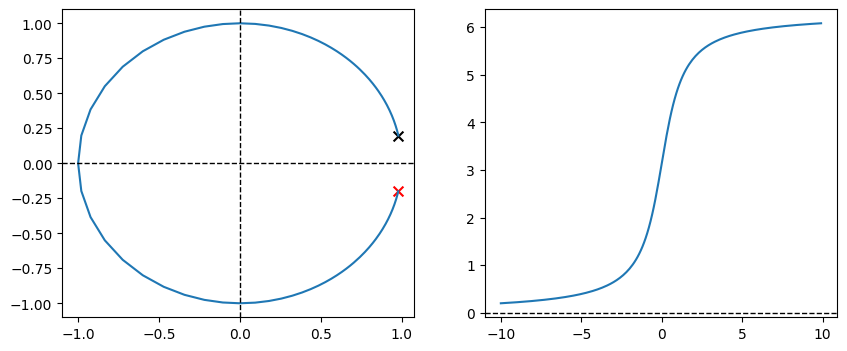

In [2]:
# I < 0
R = 0
I = -1

eps = np.arange(-10, 10, 0.1)

energy_term, phase, ext1, ext2, _, _ = plot(R, I, eps, absorption=False)

3.141592653589793 3.141592653589793


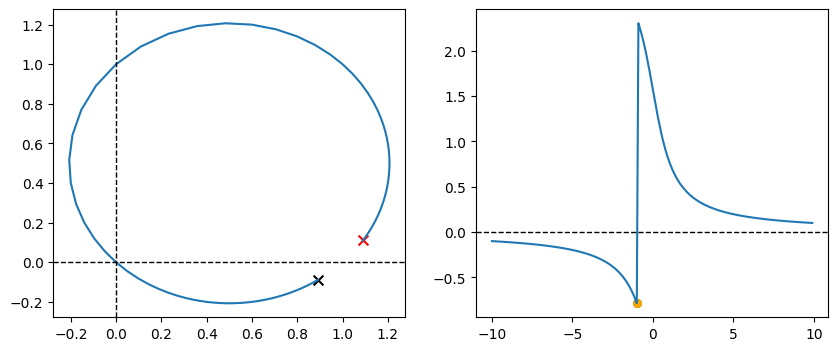

In [3]:
# I = 0
R = 1
I = 0

eps = np.arange(-10, 10, 0.1)

energy_term, phase, ext1, ext2, phase_ext1, phase_ext2 = plot(R, I, eps, absorption=True)
print(np.pi, analyt_jump(R, I))

3.141592653589793 3.141592653589793


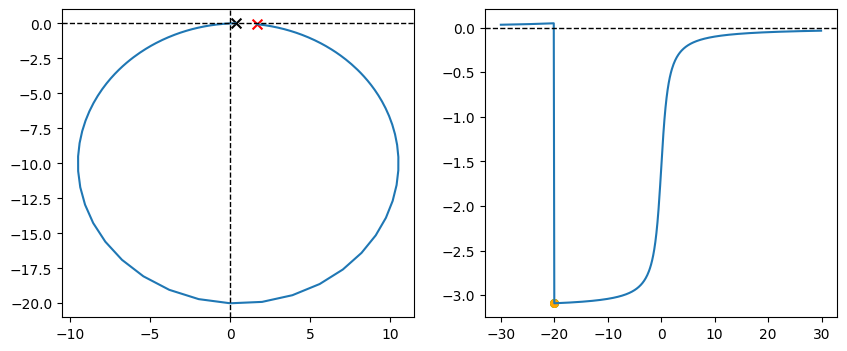

In [4]:
# I = 0
R = 20
I = 0

eps = np.arange(-30, 30, 0.1)

energy_term, phase, ext1, ext2, phase_ext1, phase_ext2 = plot(R, I, eps, absorption=False)
print(np.pi, analyt_jump(R, I))

2.262669669637579 2.2627062613870796


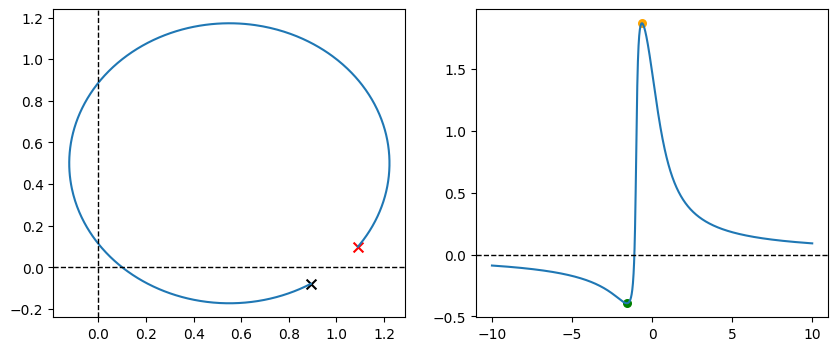

In [18]:
# 0 < I < 1
R = 1
I = 0.1

eps = np.arange(-10, 10, 0.01)

energy_term, phase, ext1, ext2, phase_ext1, phase_ext2 = plot(R, I, eps, absorption=True)


print(phase_ext2 - phase_ext1, analyt_jump(R, I))

-0.4899573262537147 0.4899573262537283


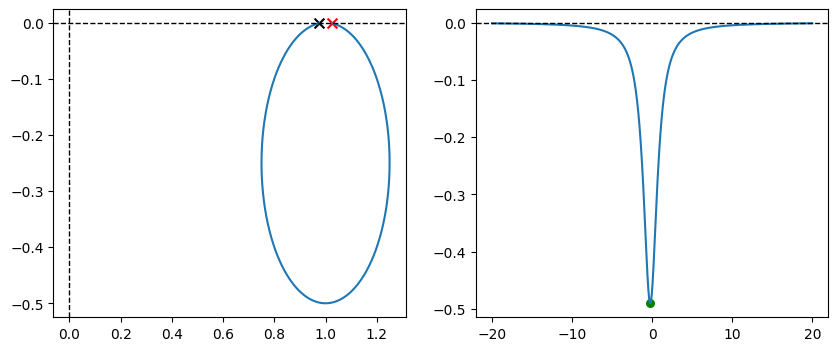

In [6]:
# I = 1
R = 0.5
I = 1

eps = np.arange(-20, 20, 0.01)

energy_term, phase, ext1, ext2, phase_ext1, phase_ext2 = plot(R, I, eps, absorption=False)


print(phase_ext1, analyt_jump(R, I))
# plt.plot([eps[0], eps[-1]], [2 * np.arctan(np.abs(R)/2), 2 * np.arctan(np.abs(R)/2)], "--")
# plt.xlim([-2, -1])

-1.0362649009365692 1.0362694582111445


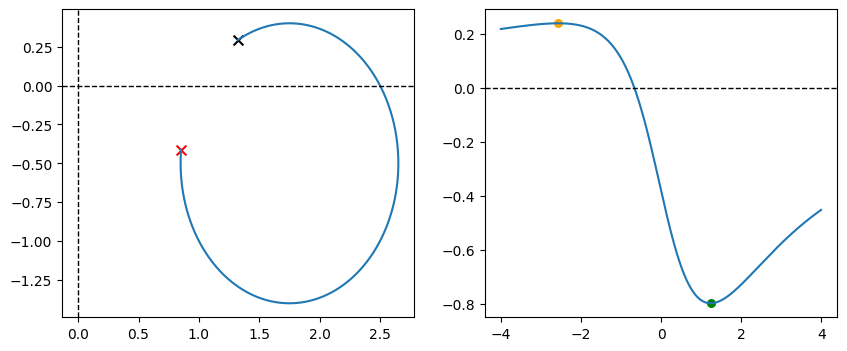

In [22]:
# I > 1
R = -1
I = 2.5

eps = np.arange(-4, 4, 0.01)

energy_term, phase, ext1, ext2, phase_ext1, phase_ext2 = plot(R, I, eps, absorption=True)


print(phase_ext1 - phase_ext2, analyt_jump(R, I))

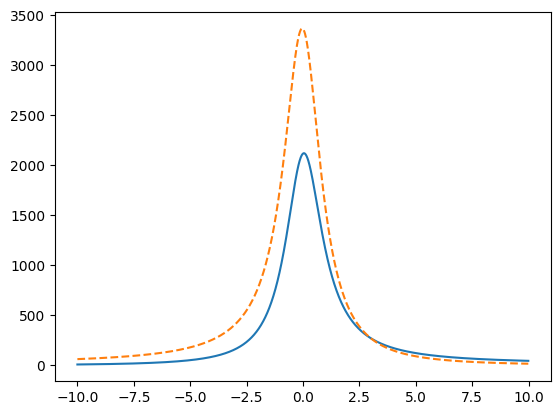

In [12]:
sigma_0 = 4
sigma_bg = 101

q_1 = 23
q_2 = -29

E_res = 0.458
gamma_res = 0.0032 
eps_min = -10
eps_max = 10
eps_plot = np.arange(eps_min, eps_max, 0.01)
cs_1 = sigma_0 * (eps_plot + q_1) ** 2 / (eps_plot ** 2 + 1)
cs_2 = sigma_0 * (eps_plot + q_2) ** 2 / (eps_plot ** 2 + 1)

plt.plot(eps_plot, cs_1)
plt.plot(eps_plot, cs_2, "--")